# Klasifikasi Naive Bayes dengan Representasi One-Hot Encoding vs Skip-gram (Word2Vec)
## Tugas PPW — Perbandingan Variasi Preprocessing & Representasi Fitur

**Dataset:** `dataset_berita.csv` (200 berita, 2 kelas: `sport` dan `finance`)

**Tujuan eksperimen:**
1. Menguji beberapa **skema preprocessing** berbeda — mulai dari yang paling minimal (hanya menghapus tanda baca) sampai yang lebih lengkap (case folding, stopword removal, stemming).
2. Menguji dua **skema representasi fitur**:
   - One-Hot Encoding (Bag-of-Words biner)
   - Word Embedding **Skip-gram** (Word2Vec dari Gensim, `sg=1`), dengan beberapa variasi parameter (`vector_size`, `window`).
3. Melatih model **Naive Bayes** untuk tiap kombinasi (preprocessing × representasi), lalu membandingkan **akurasinya** dalam satu tabel rekap.


---
## Peta Notebook

| Bagian | Isi | Fungsi |
|---|---|---|
| 1 | Setup | Import library, konstanta, dan tools Sastrawi — **satu kali di awal** |
| 2 | Load & pembersihan data | Baca CSV, deteksi kolom, buang missing value & duplikat → `df_berita` |
| 3 | EDA | Distribusi kelas, panjang dokumen, WordCloud |
| 4 | Landasan konsep Word2Vec | Demo 3 kalimat: pasangan target→konteks, vektor kata, Skip-gram vs CBOW |
| 5 | Preprocessing modular | Satu fungsi `preprocess_modular`, dipakai untuk skema P1–P4 |
| 6 | Split data | Satu pembagian latih/uji (80/20), dipakai semua eksperimen |
| 7 | Eksperimen | One-Hot + BernoulliNB vs Skip-gram + GaussianNB, semua skema & parameter |
| 8 | Rekap & visualisasi | Tabel akurasi gabungan + grafik rata-rata |
| 9 | Detail satu konfigurasi | Classification report, confusion matrix, kata terdekat |
| 10 | Kesimpulan | Interpretasi hasil |

**Alur variabel:** `df_berita` → `prep_results` → `idx_train / idx_test` → `df_onehot`, `df_skipgram` → `df_rekap`.

> Jalankan sel dari atas ke bawah. Setiap komponen (import, load data, preprocessing, split, fungsi vektor dokumen) hanya didefinisikan **satu kali**, lalu dipakai ulang oleh bagian berikutnya.

## 1. Setup

Semua import, konstanta, dan tools Sastrawi dikumpulkan di satu tempat supaya tidak ada definisi ganda.

- `SEED` — satu nilai seed untuk seluruh notebook (split data, Word2Vec, WordCloud).
- `STOPWORDS_ID` dan `STEMMER` — tools Bahasa Indonesia dari Sastrawi, dibuat sekali dan dipakai oleh EDA (WordCloud) maupun preprocessing.

Jika Gensim, Sastrawi, WordCloud, atau Seaborn belum terpasang, jalankan sekali baris `%pip install` di sel pertama (hapus tanda `#`-nya).

In [1]:
# Jalankan sekali saja jika library belum terpasang (hapus tanda '#'):
# %pip install gensim Sastrawi scikit-learn pandas matplotlib seaborn wordcloud

In [2]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay)

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")

SEED = 42

# Tools Sastrawi (stopword Bahasa Indonesia & stemmer) — dibuat sekali
STOPWORDS_ID = set(StopWordRemoverFactory().get_stop_words())
STEMMER = StemmerFactory().create_stemmer()

print("Jumlah stopword Sastrawi :", len(STOPWORDS_ID))

Jumlah stopword Sastrawi : 123


## 2. Load Dataset & Pembersihan Data

Dataset berupa **artikel berita hasil scraping dari Detik.com** dengan dua kategori, `sport` dan `finance`. Secara formal:

$$\mathcal{D} = \{(d_i, y_i)\}_{i=1}^{N}, \qquad y_i \in \{\text{sport},\ \text{finance}\}$$

Sel di bawah melakukan seluruh persiapan data **sekali saja**, dan hasil akhirnya adalah `df_berita` (kolom `teks` dan `label`) yang dipakai semua bagian berikutnya:

1. Membaca `dataset_berita.csv` (satu file berisi kedua kategori).
2. Membuang kolom **URL / link** karena tidak dipakai dalam pemodelan.
3. Mendeteksi kolom **label** dan kolom **teks berita** secara otomatis. Jika nama kolom Anda tidak ada di daftar kandidat, tambahkan namanya ke `KANDIDAT_LABEL` / `KANDIDAT_TEKS`.
4. Membersihkan data:
   - ***Missing value*** — dokumen dengan teks kosong tidak dapat diproses, sehingga dibuang.
   - **Duplikasi** — artikel identik dapat membuat data uji "bocor" ke data latih dan menggelembungkan akurasi, sehingga duplikat dibuang.

> **Sesuaikan** `DIR_DATASET` jika lokasi file berbeda.

In [3]:
DIR_DATASET = r"C:\Users\acer\OneDrive\Documents\DOKUMEN KULIAH\Semester 7\ppw"
PATH_BERITA = os.path.join(DIR_DATASET, "dataset_berita.csv")

df_raw = pd.read_csv(PATH_BERITA)
print("Kolom awal :", df_raw.columns.tolist())

# 1) Buang kolom URL / link (tidak diperlukan)
kolom_url = [c for c in df_raw.columns if any(k in c.lower() for k in ("url", "link"))]
df_raw = df_raw.drop(columns=kolom_url)
print("Kolom URL yang dibuang :", kolom_url)

# 2) Deteksi kolom label/kategori
KANDIDAT_LABEL = ["label", "kategori", "category", "kelas", "class", "topik", "rubrik"]
LABEL_COL = next((c for c in KANDIDAT_LABEL if c in df_raw.columns), None)
if LABEL_COL is None:
    raise ValueError(f"Kolom label tidak ditemukan. Kolom tersedia: {df_raw.columns.tolist()}")
print("Kolom label yang dipakai :", LABEL_COL)

# 3) Deteksi kolom teks berita
KANDIDAT_TEKS = ["isi_berita", "isi", "konten", "content", "teks", "text", "artikel", "berita", "body"]
TEXT_COL = next((c for c in KANDIDAT_TEKS if c in df_raw.columns), None)
if TEXT_COL is None:   # fallback: kolom bertipe teks dengan rata-rata karakter terpanjang
    kolom_obj = [c for c in df_raw.columns if df_raw[c].dtype == "object" and c != LABEL_COL]
    TEXT_COL = max(kolom_obj, key=lambda c: df_raw[c].astype(str).str.len().mean())
print("Kolom teks berita yang dipakai :", TEXT_COL)

df_berita = df_raw[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "teks", LABEL_COL: "label"})
print("\nUkuran dataset awal :", df_berita.shape)

# 4) Bersihkan: buang missing value & duplikat
print("\nMissing value per kolom:")
print(df_berita.isna().sum())
print("Jumlah dokumen duplikat :", df_berita.duplicated(subset="teks").sum())

df_berita = (df_berita.dropna(subset=["teks"])
                      .drop_duplicates(subset="teks")
                      .reset_index(drop=True))
print("\nUkuran dataset setelah dibersihkan :", df_berita.shape)

print("\nTipe data & info kolom:")
df_berita.info()
df_berita.head()

Kolom awal : ['id', 'isi_berita', 'label']
Kolom URL yang dibuang : []
Kolom label yang dipakai : label
Kolom teks berita yang dipakai : isi_berita

Ukuran dataset awal : (200, 2)

Missing value per kolom:
teks     0
label    0
dtype: int64
Jumlah dokumen duplikat : 0

Ukuran dataset setelah dibersihkan : (200, 2)

Tipe data & info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   teks    200 non-null    object
 1   label   200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB


,teks,label
0,Jakarta - Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untu...,sport
1,Jakarta - Mata Derrick Michael Xzavierro berbinar saat berbicara soal Asian Games 2026. Dia akan...,sport
2,Jakarta - Marc Marquez masih harus beradaptasi dengan kondisi lengan kanan yang jauh dari normal...,sport
3,Jakarta - Momen debut di Asian Games 2026 tak mau disia-siakan Alwi Farhan. Pebulutangkis tungga...,sport
4,Jakarta - MotoGP 2026 akan berlanjut ke San Marino. Seri ke-14 musim ini akan digelar di Misano ...,sport


## 3. Exploratory Data Analysis (EDA)

EDA dijalankan pada `df_berita` yang sudah bersih: melihat keseimbangan kelas, sebaran panjang dokumen, dan kosakata dominan tiap kelas.

### 3.1 Distribusi Kelas

**Proporsi kelas** menunjukkan apakah data seimbang (*balanced*):

$$p_c = \frac{N_c}{N}, \qquad \sum_{c} p_c = 1$$

Jika tiap kelas berimbang (misalnya 100 dokumen per kelas, $p_{\text{sport}} = p_{\text{finance}} = 0{,}5$), **akurasi** cukup layak dipakai sebagai metrik.

Distribusi kelas:
label
sport      100
finance    100
Name: count, dtype: int64

Proporsi kelas:
label
sport      0.5
finance    0.5
Name: proportion, dtype: float64


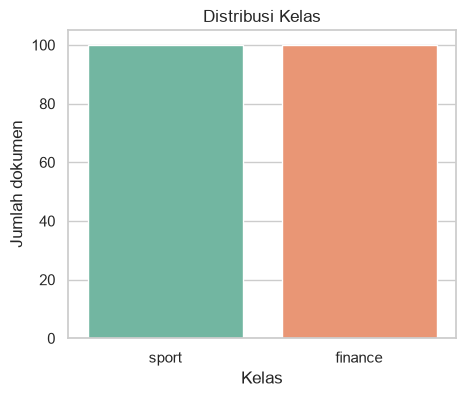

In [4]:
print("Distribusi kelas:")
print(df_berita["label"].value_counts())
print("\nProporsi kelas:")
print(df_berita["label"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=df_berita, x="label", hue="label", palette="Set2", legend=False)
plt.title("Distribusi Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah dokumen")
plt.show()

### 3.2 Panjang Kata per Dokumen

Panjang dokumen ke-$i$ dihitung sebagai jumlah kata hasil pemisahan spasi:

$$L_i = \left|\,\text{split}(d_i)\,\right|$$

Statistik deskriptif yang dilihat:

$$\bar{L} = \frac{1}{N}\sum_{i=1}^{N} L_i, \qquad s = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}\left(L_i - \bar{L}\right)^2}$$

**Boxplot** memakai kuartil $Q_1$, median, $Q_3$, dan rentang antarkuartil $IQR = Q_3 - Q_1$. Nilai dianggap ***outlier*** bila berada di luar:

$$\left[\,Q_1 - 1{,}5\cdot IQR,\;\; Q_3 + 1{,}5\cdot IQR\,\right]$$

**Histogram** menunjukkan bentuk sebaran $L_i$ (miring ke kanan, simetris, dll.). Panjang dokumen penting karena rata-rata vektor kata pada dokumen yang sangat pendek cenderung kurang stabil.

Statistik deskriptif jumlah kata per dokumen:
count     200.00
mean      340.39
std       156.96
min        18.00
25%       264.50
50%       328.00
75%       399.00
max      1077.00
Name: jumlah_kata, dtype: float64

Statistik per kelas:
         count    mean     std   min    25%    50%    75%     max
label                                                            
finance  100.0  336.11  189.43  18.0  232.0  325.0  401.5  1077.0
sport    100.0  344.67  116.64  21.0  270.5  331.0  393.0   753.0

Q1=264, Q3=399, IQR=134 -> batas outlier [63, 601]
Jumlah dokumen outlier : 21


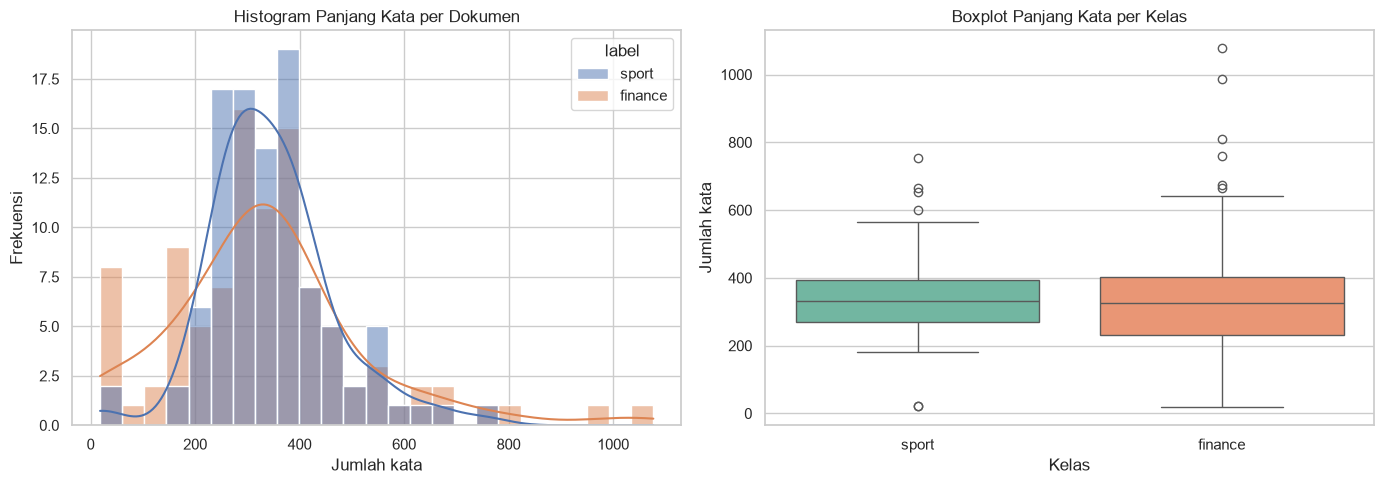

In [5]:
df_berita["jumlah_kata"] = df_berita["teks"].astype(str).str.split().str.len()

print("Statistik deskriptif jumlah kata per dokumen:")
print(df_berita["jumlah_kata"].describe().round(2))

print("\nStatistik per kelas:")
print(df_berita.groupby("label")["jumlah_kata"].describe().round(2))

q1, q3 = df_berita["jumlah_kata"].quantile([0.25, 0.75])
iqr = q3 - q1
batas_bawah, batas_atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_outlier = ((df_berita["jumlah_kata"] < batas_bawah) | (df_berita["jumlah_kata"] > batas_atas)).sum()
print(f"\nQ1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f} -> batas outlier [{batas_bawah:.0f}, {batas_atas:.0f}]")
print("Jumlah dokumen outlier :", n_outlier)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_berita, x="jumlah_kata", hue="label", bins=25, kde=True, ax=axes[0])
axes[0].set_title("Histogram Panjang Kata per Dokumen")
axes[0].set_xlabel("Jumlah kata")
axes[0].set_ylabel("Frekuensi")

sns.boxplot(data=df_berita, x="label", y="jumlah_kata", hue="label", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Boxplot Panjang Kata per Kelas")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah kata")

plt.tight_layout()
plt.show()

### 3.3 WordCloud

**WordCloud** menampilkan kata-kata dengan ukuran huruf sebanding dengan frekuensinya. Frekuensi kata $w$ pada kelas $c$:

$$f_c(w) = \sum_{i:\,y_i = c} \text{count}(w, d_i)$$

Agar WordCloud informatif, kata-kata umum (*stopword*) dibuang lebih dulu. Kata yang menonjol pada tiap kelas memberi gambaran awal apakah kedua kategori **memiliki kosakata yang berbeda** (indikasi bahwa klasifikasi akan relatif mudah).

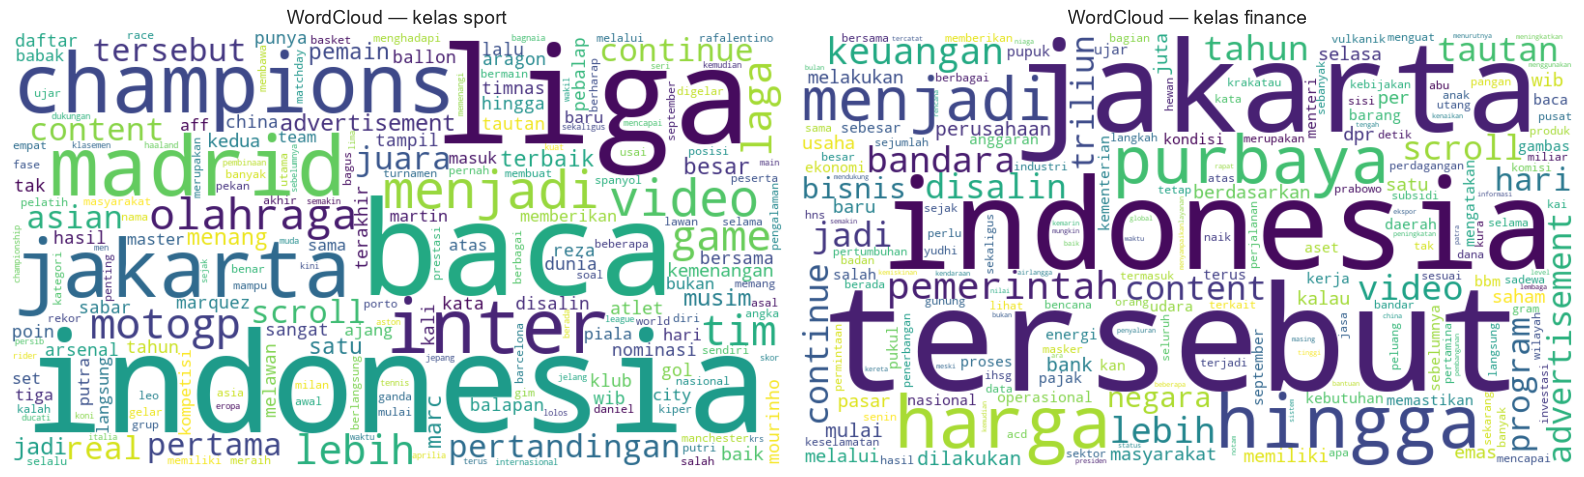

In [6]:
def teks_untuk_wordcloud(serial_teks):
    gabungan = " ".join(serial_teks.astype(str)).lower()
    kata = re.findall(r"[a-z]{3,}", gabungan)
    return " ".join(k for k in kata if k not in STOPWORDS_ID)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, kelas in zip(axes, ["sport", "finance"]):
    teks_kelas = teks_untuk_wordcloud(df_berita.loc[df_berita["label"] == kelas, "teks"])
    wc = WordCloud(width=800, height=450, background_color="white",
                   collocations=False, random_state=SEED).generate(teks_kelas)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"WordCloud — kelas {kelas}", fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Landasan Konsep Word2Vec (Skip-gram)

Bagian ini menjelaskan cara kerja Skip-gram pada 3 kalimat sederhana sebelum diterapkan ke data berita. Bagian ini **berdiri sendiri** dan tidak bergantung pada dataset.

### 4.1 Dataset Mini & Parameter Utama

**Word2Vec** adalah metode *word embedding* yang memetakan setiap kata $w$ ke sebuah vektor bilangan real berdimensi tetap:

$$f: w \;\longmapsto\; \mathbf{v}_w \in \mathbb{R}^{d}$$

Kata-kata yang sering muncul pada **konteks yang mirip** akan memiliki vektor yang saling berdekatan. Dua parameter utama yang dijelaskan pada demo ini:

| Parameter Gensim | Notasi | Arti |
|---|---|---|
| `vector_size` | $d$ | Dimensi vektor tiap kata. Makin besar, makin kaya informasi, tetapi butuh data lebih banyak |
| `window` (`window_size`) | $c$ | Jumlah kata di **kiri** dan **kanan** target yang dianggap sebagai konteks |
| `sg` | – | `sg=1` → **Skip-gram**, `sg=0` → **CBOW** |
| `min_count` | – | Kata dengan frekuensi di bawah nilai ini diabaikan |

**Jendela konteks.** Untuk korpus berupa barisan kata $w_1, w_2, \dots, w_T$, konteks dari kata target pada posisi $t$ adalah:

$$C(t) = \{\, w_{t+j} \;\mid\; -c \le j \le c,\; j \neq 0,\; 1 \le t+j \le T \,\}$$

Sehingga setiap target menghasilkan paling banyak $2c$ pasangan, dan total pasangan pada satu kalimat paling banyak $2cT$ (kata di ujung kalimat punya konteks lebih sedikit).

In [7]:
# Dataset mini: 3 kalimat sederhana (sudah huruf kecil & tanpa tanda baca)
kalimat_demo = [
    "harga saham bank naik hari ini",
    "investor membeli saham bank besar",
    "pemain bola mencetak gol indah",
]
korpus_demo = [k.split() for k in kalimat_demo]

VECTOR_SIZE_DEMO = 5   # d : dimensi vektor tiap kata
WINDOW_SIZE_DEMO = 2   # c : jumlah kata di kiri/kanan target

for i, tokens in enumerate(korpus_demo, start=1):
    print(f"Kalimat {i}: {tokens}")

vocab_demo = sorted({t for kal in korpus_demo for t in kal})
print("\nKosakata :", vocab_demo)
print("Ukuran kosakata (V) :", len(vocab_demo))
print("vector_size (d)     :", VECTOR_SIZE_DEMO)
print("window_size (c)     :", WINDOW_SIZE_DEMO)

Kalimat 1: ['harga', 'saham', 'bank', 'naik', 'hari', 'ini']
Kalimat 2: ['investor', 'membeli', 'saham', 'bank', 'besar']
Kalimat 3: ['pemain', 'bola', 'mencetak', 'gol', 'indah']

Kosakata : ['bank', 'besar', 'bola', 'gol', 'harga', 'hari', 'indah', 'ini', 'investor', 'membeli', 'mencetak', 'naik', 'pemain', 'saham']
Ukuran kosakata (V) : 14
vector_size (d)     : 5
window_size (c)     : 2


### Penjelasan Output

Kode tersebut digunakan untuk **menyiapkan dataset sederhana sebelum proses Word2Vec**.

- **Kalimat 1–3** → menampilkan setiap kalimat yang sudah dipecah menjadi kata/token.
- **Kosakata** → menampilkan semua kata unik yang terdapat dalam 3 kalimat.
- **Ukuran kosakata (V)** → menunjukkan jumlah kata unik dalam dataset.
- **vector_size (d) = 5** → setiap kata nantinya direpresentasikan dalam **5 dimensi**.
- **window_size (c) = 2** → Word2Vec menggunakan maksimal **2 kata di kiri dan 2 kata di kanan** sebagai konteks kata target.

**Kesimpulan:** Kode ini berfungsi untuk menyiapkan **korpus, kosakata, dan parameter Word2Vec** sebelum proses pembentukan vektor kata.

### 4.2 Ekstraksi Kombinasi Pasangan Target $\rightarrow$ Konteks

Pada Skip-gram, **kata target** dipakai untuk **memprediksi setiap kata konteksnya**. Maka setiap target dipasangkan satu per satu dengan kata-kata di sekitarnya, menghasilkan sampel latih berbentuk $(w_t, w_{t+j})$.

Contoh dengan $c = 2$ pada kalimat `harga saham bank naik hari ini`, target `saham`:

$$\text{saham} \rightarrow \{\text{harga},\ \text{bank},\ \text{naik}\}$$

**Fungsi tujuan (objective)** Skip-gram: memaksimalkan rata-rata log-probabilitas kata konteks terhadap kata target.

$$J(\theta) = \frac{1}{T} \sum_{t=1}^{T} \;\sum_{\substack{-c \le j \le c \\ j \ne 0}} \log P(w_{t+j} \mid w_t)$$

Probabilitas dimodelkan dengan **softmax** atas seluruh kosakata ($V$ kata), dengan $\mathbf{v}$ = vektor *input* (target) dan $\mathbf{u}$ = vektor *output* (konteks):

$$P(w_O \mid w_I) = \frac{\exp\!\left(\mathbf{u}_{w_O}^{\top}\mathbf{v}_{w_I}\right)}{\sum_{w=1}^{V} \exp\!\left(\mathbf{u}_{w}^{\top}\mathbf{v}_{w_I}\right)}$$

Karena penyebut softmax mahal dihitung ketika $V$ besar, Gensim (default `negative=5`) memakai ***Negative Sampling***. Untuk tiap pasangan $(w_I, w_O)$ yang dimaksimalkan adalah:

$$\log \sigma\!\left(\mathbf{u}_{w_O}^{\top}\mathbf{v}_{w_I}\right) + \sum_{k=1}^{K} \mathbb{E}_{w_k \sim P_n(w)} \Big[ \log \sigma\!\left(-\mathbf{u}_{w_k}^{\top}\mathbf{v}_{w_I}\right) \Big], \qquad \sigma(x) = \frac{1}{1+e^{-x}}$$

dengan $K$ = jumlah sampel negatif dan $P_n(w) \propto U(w)^{3/4}$ (distribusi unigram dipangkatkan $3/4$).

> **Catatan:** fungsi `ekstrak_kombinasi_skipgram` di bawah memakai *window* **tetap** agar mudah dipahami. Pada Gensim, ukuran window efektif tiap target diambil acak antara $1$ dan `window`, sehingga kata yang lebih dekat lebih sering menjadi konteks.

In [8]:
def ekstrak_kombinasi_skipgram(tokens, window_size=2):
    """
    Mengembalikan list pasangan (target, konteks) untuk satu kalimat.
    Tiap kata dijadikan target, lalu dipasangkan dengan kata-kata di
    sekitarnya sejauh `window_size` di kiri dan kanan.
    """
    pasangan = []
    for i, target in enumerate(tokens):
        awal = max(0, i - window_size)
        akhir = min(len(tokens), i + window_size + 1)
        for j in range(awal, akhir):
            if j != i:                      # kata target tidak dipasangkan dengan dirinya sendiri
                pasangan.append((target, tokens[j]))
    return pasangan


# Contoh pada kalimat pertama
pasangan_k1 = ekstrak_kombinasi_skipgram(korpus_demo[0], WINDOW_SIZE_DEMO)

print(f"Kalimat : {korpus_demo[0]}\n")
for target in korpus_demo[0]:
    konteks = [k for t, k in pasangan_k1 if t == target]
    print(f"{target:8s} -> {konteks}")

total_pasangan = sum(len(ekstrak_kombinasi_skipgram(k, WINDOW_SIZE_DEMO)) for k in korpus_demo)
print(f"\nTotal pasangan (target, konteks) pada 3 kalimat : {total_pasangan}")

df_pasangan = pd.DataFrame(pasangan_k1, columns=["target", "konteks"])
df_pasangan

Kalimat : ['harga', 'saham', 'bank', 'naik', 'hari', 'ini']

harga    -> ['saham', 'bank']
saham    -> ['harga', 'bank', 'naik']
bank     -> ['harga', 'saham', 'naik', 'hari']
naik     -> ['saham', 'bank', 'hari', 'ini']
hari     -> ['bank', 'naik', 'ini']
ini      -> ['naik', 'hari']

Total pasangan (target, konteks) pada 3 kalimat : 46


,target,konteks
0,harga,saham
1,harga,bank
2,saham,harga
3,saham,bank
4,saham,naik
5,bank,harga
6,bank,saham
7,bank,naik
8,bank,hari
9,naik,saham


### Penjelasan Output

Kode tersebut digunakan untuk **membentuk pasangan kata target dan kata konteks menggunakan metode Skip-gram** dengan `window_size = 2`.

- **Target** → kata yang sedang diproses.
- **Konteks** → kata-kata yang berada maksimal **2 posisi di kiri atau kanan** dari target.
- Kata target **tidak dipasangkan dengan dirinya sendiri**.

Contohnya pada kalimat:

`harga saham bank naik hari ini`

Untuk kata **"bank"**, konteksnya adalah:

`harga, saham, naik, hari`

karena keempat kata tersebut berada dalam jarak maksimal 2 kata dari **"bank"**.

Output tabel `target` dan `konteks` menunjukkan seluruh pasangan kata yang berhasil dibentuk dari kalimat pertama.

**Total 46 pasangan** menunjukkan jumlah seluruh pasangan `(target, konteks)` yang terbentuk dari **3 kalimat**.

**Kesimpulan:** Tahap ini mengubah kalimat menjadi pasangan **kata target–kata konteks** yang nantinya digunakan sebagai data pembelajaran Word2Vec Skip-gram.

### 4.3 Melatih Word2Vec Skip-gram & Mengambil Vektor Kata `saham`

Setelah model dilatih (`sg=1`), setiap kata di kosakata memiliki vektor pada `model.wv`. Secara matematis, jika $W \in \mathbb{R}^{V \times d}$ adalah matriks bobot *input*, dan $\mathbf{x}_w$ adalah *one-hot vector* kata $w$, maka vektor kata adalah baris ke-$w$ dari $W$:

$$\mathbf{v}_w = W^{\top}\mathbf{x}_w$$

Kedekatan makna dua kata diukur dengan **cosine similarity**:

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert \, \lVert\mathbf{b}\rVert} = \frac{\sum_{i=1}^{d} a_i b_i}{\sqrt{\sum_{i=1}^{d} a_i^2}\;\sqrt{\sum_{i=1}^{d} b_i^2}}$$

Nilainya berkisar $-1$ (berlawanan) sampai $1$ (searah).

> **Catatan:** korpus demo hanya 3 kalimat, jadi angka vektor & kemiripan yang keluar **hanya untuk ilustrasi cara kerja**, bukan untuk ditafsirkan secara semantik.

In [9]:
model_sg_demo = Word2Vec(
    sentences=korpus_demo,
    vector_size=VECTOR_SIZE_DEMO,
    window=WINDOW_SIZE_DEMO,
    min_count=1,
    sg=1,            # Skip-gram
    epochs=100,      # korpus sangat kecil -> perbanyak epoch
    seed=SEED,
    workers=1,
)

vektor_saham = model_sg_demo.wv["saham"]
print("Vektor kata 'saham' (Skip-gram):")
print(np.round(vektor_saham, 4))
print("Bentuk vektor :", vektor_saham.shape)


def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


print("\nCosine similarity terhadap 'saham':")
for kata in ["bank", "investor", "gol", "pemain"]:
    sim = cosine_similarity(model_sg_demo.wv["saham"], model_sg_demo.wv[kata])
    print(f"  saham vs {kata:9s}: {sim:.4f}")

Vektor kata 'saham' (Skip-gram):
[ 0.1428 -0.1651  0.0782 -0.1188 -0.1623]
Bentuk vektor : (5,)

Cosine similarity terhadap 'saham':
  saham vs bank     : -0.4577
  saham vs investor : 0.1880
  saham vs gol      : -0.1316
  saham vs pemain   : -0.3315


#### Penjelasan Output

Kode tersebut digunakan untuk **melatih model Word2Vec dengan metode Skip-gram** dan melihat hubungan antara kata **"saham"** dengan kata lainnya.

- **Vektor kata "saham"** → kata `saham` direpresentasikan menjadi **5 angka** karena `vector_size=5`.
  - `[0.1428, -0.1651, 0.0782, -0.1188, -0.1623]`
- **Bentuk vektor `(5,)`** → menunjukkan bahwa vektor `saham` memiliki **5 dimensi**.
- **Cosine similarity** → digunakan untuk mengukur tingkat kemiripan arah vektor antara `saham` dengan kata lainnya.
  - `saham vs bank = -0.4577`
  - `saham vs investor = 0.1880`
  - `saham vs gol = -0.1316`
  - `saham vs pemain = -0.3315`

Semakin mendekati **1**, semakin mirip arah vektornya. Nilai mendekati **0** menunjukkan hubungan yang rendah, sedangkan nilai **negatif** menunjukkan arah vektor yang berlawanan.

**Catatan:** Karena dataset hanya terdiri dari **3 kalimat dan sangat kecil**, nilai similarity tersebut belum dapat dianggap sebagai gambaran hubungan kata yang sebenarnya. Model membutuhkan korpus yang lebih besar agar representasi vektornya lebih bermakna.

**Kesimpulan:** Word2Vec mengubah setiap kata menjadi vektor 5 dimensi, kemudian **cosine similarity** digunakan untuk membandingkan kemiripan antarvektor kata.

#### 4.4 Perbandingan Arsitektur: Skip-gram vs CBOW

Kedua arsitektur memakai jendela konteks yang sama, tetapi arah prediksinya berlawanan.

**Skip-gram** — target $\rightarrow$ konteks:

$$J_{\text{SG}} = \frac{1}{T}\sum_{t=1}^{T}\sum_{w_c \in C(t)} \log P(w_c \mid w_t)$$

**CBOW** (*Continuous Bag-of-Words*) — konteks $\rightarrow$ target. Vektor konteks dirata-ratakan lebih dulu:

$$\bar{\mathbf{v}}_{C(t)} = \frac{1}{|C(t)|}\sum_{w_c \in C(t)} \mathbf{v}_{w_c}, \qquad P(w_t \mid C(t)) = \frac{\exp\!\left(\mathbf{u}_{w_t}^{\top}\bar{\mathbf{v}}_{C(t)}\right)}{\sum_{w=1}^{V}\exp\!\left(\mathbf{u}_{w}^{\top}\bar{\mathbf{v}}_{C(t)}\right)}$$

$$J_{\text{CBOW}} = \frac{1}{T}\sum_{t=1}^{T}\log P(w_t \mid C(t))$$

| Aspek | Skip-gram | CBOW |
|---|---|---|
| Input $\rightarrow$ Output | 1 kata target $\rightarrow$ banyak kata konteks | Banyak kata konteks $\rightarrow$ 1 kata target |
| Jumlah sampel latih per posisi | Hingga $2c$ pasangan | 1 sampel (konteks dirata-rata) |
| Kecepatan latih | Lebih lambat | Lebih cepat |
| Kata jarang (*rare words*) | Lebih baik | Kurang baik (terlalu "ter-rata-rata") |
| Cocok untuk | Dataset kecil / kosakata jarang | Dataset besar, kata frekuensi tinggi |
| Parameter Gensim | `sg=1` | `sg=0` |

In [10]:
model_cbow_demo = Word2Vec(
    sentences=korpus_demo,
    vector_size=VECTOR_SIZE_DEMO,
    window=WINDOW_SIZE_DEMO,
    min_count=1,
    sg=0,            # CBOW
    epochs=100,
    seed=SEED,
    workers=1,
)

df_bandingkan = pd.DataFrame({
    "dimensi": range(1, VECTOR_SIZE_DEMO + 1),
    "Skip-gram (sg=1)": np.round(model_sg_demo.wv["saham"], 4),
    "CBOW (sg=0)": np.round(model_cbow_demo.wv["saham"], 4),
})
print("Vektor kata 'saham' pada dua arsitektur:")
display(df_bandingkan)

# Jumlah sampel latih yang dihasilkan tiap arsitektur (1 epoch, window tetap)
n_skipgram = sum(len(ekstrak_kombinasi_skipgram(k, WINDOW_SIZE_DEMO)) for k in korpus_demo)
n_cbow = sum(len(k) for k in korpus_demo)
print(f"Sampel latih Skip-gram (target, konteks) : {n_skipgram}")
print(f"Sampel latih CBOW (konteks -> target)    : {n_cbow}")

print("\nCatatan: angka vektor kedua model bisa tampak mirip karena inisialisasi acak (seed) sama")
print("dan korpus sangat kecil. Perbedaan utamanya ada pada CARA latih (jumlah sampel & arah prediksi).")

Vektor kata 'saham' pada dua arsitektur:


,dimensi,Skip-gram (sg=1),CBOW (sg=0)
0,1,0.1428,0.1433
1,2,-0.1651,-0.1650
2,3,0.0782,0.0784
3,4,-0.1188,-0.1190
4,5,-0.1623,-0.1624


Sampel latih Skip-gram (target, konteks) : 46
Sampel latih CBOW (konteks -> target)    : 16

Catatan: angka vektor kedua model bisa tampak mirip karena inisialisasi acak (seed) sama
dan korpus sangat kecil. Perbedaan utamanya ada pada CARA latih (jumlah sampel & arah prediksi).


### 5. Preprocessing Modular

Preprocessing dibuat **modular**: tiap langkah adalah fungsi kecil yang dapat dinyalakan/dimatikan lewat parameter. Secara matematis, preprocessing adalah komposisi fungsi dari teks mentah $d$ menjadi barisan token:

$$\text{preprocess}(d) = \left(g_6 \circ g_5 \circ g_4 \circ g_3 \circ g_2 \circ g_1\right)(d) = [\,t_1, t_2, \dots, t_n\,]$$

| Fungsi | Langkah | Contoh |
|---|---|---|
| $g_1$ | *Case folding* — ubah ke huruf kecil | `Saham` → `saham` |
| $g_2$ | Hapus tanda baca | `Jakarta - Harga,` → `Jakarta   Harga ` |
| $g_3$ | Hapus angka | `2026` → (dibuang) |
| $g_4$ | Tokenisasi (pisah spasi) | `"harga saham"` → `["harga","saham"]` |
| $g_5$ | *Stopword removal* (Sastrawi) | `yang`, `dengan`, `untuk` dibuang |
| $g_6$ | *Stemming* (Sastrawi) | `menyebut` → `sebut` |

***Stopword removal*** menyaring token yang ada di himpunan stopword $S$:

$$T' = \{\, t \in T \mid t \notin S \,\}$$

***Stemming*** memetakan tiap kata berimbuhan ke kata dasarnya, $\text{stem}(t) = t_{\text{dasar}}$. Sastrawi berbasis algoritma Nazief–Adriani untuk Bahasa Indonesia. Karena stemming lambat, hasilnya di-*cache* per kata unik.

Token yang panjangnya kurang dari `min_len` (default 2 huruf) juga dibuang karena hampir tidak membawa makna.

#### Skema P1–P4 (bertingkat)

Empat skema dibuat dari **fungsi yang sama** dengan menyalakan/mematikan flag. Tiap skema menambahkan satu langkah dari skema sebelumnya, sehingga efek tiap langkah terhadap akurasi terlihat jelas:

| Skema | `do_case_folding` | `do_stopwords` | `do_stemming` | Keterangan |
|---|---|---|---|---|
| `P1_tanda_baca` | ✗ | ✗ | ✗ | Baseline: hanya menghapus tanda baca |
| `P2_lower` | ✓ | ✗ | ✗ | + case folding |
| `P3_stopword` | ✓ | ✓ | ✗ | + stopword removal |
| `P4_stem` | ✓ | ✓ | ✓ | + stemming |

Pada keempat skema `do_hapus_angka=False` dan `min_len=1`, sehingga angka dan token 1 huruf tidak dibuang (sama dengan versi awal notebook). Ubah nilainya jika ingin menguji efek pembuangan angka.

Fungsi mengembalikan **list token**, bukan string, sehingga bisa dipakai langsung baik untuk One-Hot Encoding maupun untuk melatih Word2Vec. Dengan begitu perbandingannya adil (*apple-to-apple*).

In [11]:
_cache_stem = {}


def case_folding(text):
    return str(text).lower()


def hapus_tanda_baca(text):
    return re.sub(r"[^\w\s]", " ", text)


def hapus_angka(text):
    return re.sub(r"\d+", " ", text)


def tokenisasi(text):
    return re.sub(r"\s+", " ", text).strip().split()


def hapus_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS_ID]


def stemming(tokens):
    hasil = []
    for t in tokens:
        if t not in _cache_stem:
            _cache_stem[t] = STEMMER.stem(t)
        hasil.append(_cache_stem[t])
    return hasil


def preprocess_modular(text,
                       do_case_folding=True,
                       do_hapus_tanda_baca=True,
                       do_hapus_angka=True,
                       do_stopwords=True,
                       do_stemming=True,
                       min_len=2):
    """Teks mentah -> list of tokens siap masuk Word2Vec."""
    text = str(text)
    if do_case_folding:
        text = case_folding(text)
    if do_hapus_tanda_baca:
        text = hapus_tanda_baca(text)
    if do_hapus_angka:
        text = hapus_angka(text)
    tokens = tokenisasi(text)
    if do_stopwords:
        tokens = hapus_stopwords(tokens)
    if do_stemming:
        tokens = stemming(tokens)
    return [t for t in tokens if len(t) >= min_len]

Sel berikut menerapkan keempat skema ke seluruh dokumen dan menyimpan hasilnya di `prep_results` (dictionary: nama skema → Series berisi list token). `prep_results` dipakai oleh seluruh eksperimen di bagian 7. Stemming hanya lambat pada `P4_stem` saat pertama kali dijalankan, karena hasilnya di-*cache* per kata unik.

In [12]:
PREP_CONFIGS = {
    "P1_tanda_baca": dict(do_case_folding=False, do_stopwords=False, do_stemming=False),
    "P2_lower":      dict(do_case_folding=True,  do_stopwords=False, do_stemming=False),
    "P3_stopword":   dict(do_case_folding=True,  do_stopwords=True,  do_stemming=False),
    "P4_stem":       dict(do_case_folding=True,  do_stopwords=True,  do_stemming=True),
}
# Sama untuk semua skema: angka tidak dibuang, token 1 huruf dipertahankan
PARAM_UMUM = dict(do_hapus_angka=False, min_len=1)

prep_results = {}
for nama, cfg in PREP_CONFIGS.items():
    print(f"Memproses skema: {nama} ...")
    prep_results[nama] = df_berita["teks"].apply(preprocess_modular, **cfg, **PARAM_UMUM)

# Contoh sebelum & sesudah untuk dokumen pertama
print("\nTEKS ASLI (300 karakter pertama):")
print(df_berita.loc[0, "teks"][:300])
for nama in PREP_CONFIGS:
    print(f"\n[{nama}] ->", prep_results[nama][0][:15])

# Statistik token untuk skema paling lengkap (P4)
semua_token = [t for dok in prep_results["P4_stem"] for t in dok]
print("\nStatistik skema P4_stem")
print("Total token            :", len(semua_token))
print("Ukuran kosakata unik   :", len(set(semua_token)))
print("Rata-rata token/dokumen:", round(np.mean([len(d) for d in prep_results["P4_stem"]]), 1))
print("10 token terbanyak     :", Counter(semua_token).most_common(10))

Memproses skema: P1_tanda_baca ...
Memproses skema: P2_lower ...
Memproses skema: P3_stopword ...
Memproses skema: P4_stem ...

TEKS ASLI (300 karakter pertama):
Jakarta - Putri Kusuma Wardani percaya diri dengan komposisi beregu putri yang dipilih PBSI untuk Asian Games 2026. Dia juga menyebut chemistry satu sama lain sudah klop. Bulutangkis Indonesia mengirimkan 20 wakil untuk tampil di Aichi-Nagoya, 19 September hingga 4 Oktober mendatang. 10 Atlet di ant

[P1_tanda_baca] -> ['Jakarta', 'Putri', 'Kusuma', 'Wardani', 'percaya', 'diri', 'dengan', 'komposisi', 'beregu', 'putri', 'yang', 'dipilih', 'PBSI', 'untuk', 'Asian']

[P2_lower] -> ['jakarta', 'putri', 'kusuma', 'wardani', 'percaya', 'diri', 'dengan', 'komposisi', 'beregu', 'putri', 'yang', 'dipilih', 'pbsi', 'untuk', 'asian']

[P3_stopword] -> ['jakarta', 'putri', 'kusuma', 'wardani', 'percaya', 'diri', 'komposisi', 'beregu', 'putri', 'dipilih', 'pbsi', 'asian', 'games', '2026', 'menyebut']

[P4_stem] -> ['jakarta', 'putri', 'ku

### 6. Split Data (Sekali untuk Semua Eksperimen)

Label di-*encode* menjadi angka (`sport` = 0, `finance` = 1), lalu data dibagi **80% latih / 20% uji** secara *stratified* (proporsi kelas terjaga) dengan `random_state` tetap.

Yang disimpan adalah **indeks** (`idx_train`, `idx_test`), bukan salinan data. Dengan begitu skema preprocessing mana pun dan representasi mana pun memakai **dokumen uji yang persis sama**, sehingga perbandingan akurasinya adil.

In [13]:
PETA_LABEL = {"sport": 0, "finance": 1}

if not df_berita["label"].isin(PETA_LABEL).all():
    raise ValueError(f"Label tak dikenal. Isi kolom label: {df_berita['label'].unique().tolist()}")

y = df_berita["label"].map(PETA_LABEL).values

idx_train, idx_test = train_test_split(
    np.arange(len(df_berita)),
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
y_train, y_test = y[idx_train], y[idx_test]

print("Jumlah data latih :", len(idx_train))
print("Jumlah data uji   :", len(idx_test))

Jumlah data latih : 160
Jumlah data uji   : 40


### 7. Eksperimen: One-Hot Encoding vs Skip-gram

Setiap kombinasi **(skema preprocessing × representasi fitur)** dijalankan dengan bahan yang sama: `prep_results` (bagian 5) dan `idx_train / idx_test` (bagian 6). Hasil tiap representasi disimpan dalam DataFrame dengan kolom yang sama (`preprocessing`, `representasi`, `parameter`, `akurasi`) agar mudah digabung di bagian 8.

Kedua representasi dilatih **hanya dari dokumen latih** (kosakata One-Hot dan model Word2Vec), sehingga dokumen uji benar-benar tidak terlihat oleh model.

#### 7.1 Representasi 1 — One-Hot Encoding + Naive Bayes

Fitur dibuat biner: 1 jika suatu kata muncul di dokumen, 0 jika tidak (One-Hot / Bag-of-Words biner).
Karena fiturnya biner, classifier yang dipakai adalah **BernoulliNB**.

Dijalankan untuk **setiap skema preprocessing** (P1–P4) agar terlihat pengaruh preprocessing terhadap One-Hot Encoding.


Kosakata `CountVectorizer` dipelajari **hanya dari dokumen latih**. Kata yang hanya muncul di dokumen uji diabaikan.

In [14]:
def evaluasi_one_hot(tokens_series, idx_train, idx_test, y_train, y_test):
    tokens = tokens_series.tolist()

    # Token hasil preprocessing dipakai apa adanya (tanpa tokenisasi ulang oleh CountVectorizer)
    vectorizer = CountVectorizer(
        tokenizer=lambda x: x,
        preprocessor=lambda x: x,
        lowercase=False,
        token_pattern=None,
        binary=True          # -> One-Hot Encoding
    )
    X_train = vectorizer.fit_transform([tokens[i] for i in idx_train])   # kosakata dari data latih saja
    X_test = vectorizer.transform([tokens[i] for i in idx_test])

    model = BernoulliNB()
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))


hasil_onehot = []
for nama_skema, tokens_series in prep_results.items():
    akurasi = evaluasi_one_hot(tokens_series, idx_train, idx_test, y_train, y_test)
    hasil_onehot.append({
        "preprocessing": nama_skema,
        "representasi": "One-Hot Encoding",
        "parameter": "-",
        "akurasi": akurasi
    })
    print(f"{nama_skema:15s} | One-Hot Encoding | akurasi = {akurasi:.4f}")

df_onehot = pd.DataFrame(hasil_onehot)
df_onehot

P1_tanda_baca   | One-Hot Encoding | akurasi = 1.0000
P2_lower        | One-Hot Encoding | akurasi = 1.0000
P3_stopword     | One-Hot Encoding | akurasi = 1.0000
P4_stem         | One-Hot Encoding | akurasi = 1.0000


,preprocessing,representasi,parameter,akurasi
0,P1_tanda_baca,One-Hot Encoding,-,1.0
1,P2_lower,One-Hot Encoding,-,1.0
2,P3_stopword,One-Hot Encoding,-,1.0
3,P4_stem,One-Hot Encoding,-,1.0


#### 7.2 Representasi 2 — Skip-gram (Word2Vec) + Naive Bayes

Langkah:
1. Latih model **Skip-gram** (`Word2Vec(..., sg=1)`) dari Gensim menggunakan token hasil preprocessing **pada dokumen latih saja** (dokumen uji tidak boleh ikut agar tidak terjadi *data leakage*).
2. Ubah tiap dokumen menjadi 1 vektor dengan cara **rata-rata (average) vektor semua kata** di dalamnya.
3. Karena hasilnya berupa bilangan real (bisa negatif), classifier yang dipakai adalah **GaussianNB**.

Diuji dengan **variasi parameter**: `vector_size` (dimensi embedding) dan `window` (ukuran konteks), untuk **setiap skema preprocessing**.


##### Document Vector (rata-rata vektor kata)

Word2Vec menghasilkan vektor **per kata**, sedangkan klasifikasi butuh **satu vektor per dokumen**. Untuk dokumen ke-$i$ dengan $n_i$ token $t_{i1}, \dots, t_{in_i}$:

$$\mathbf{d}_i = \frac{1}{n_i}\sum_{k=1}^{n_i}\mathbf{v}_{t_{ik}}, \qquad \mathbf{d}_i \in \mathbb{R}^{d}$$

Jika tidak ada token yang dikenali ($n_i = 0$), dipakai vektor nol $\mathbf{d}_i = \mathbf{0}$. Hasil akhirnya adalah matriks fitur $X \in \mathbb{R}^{N \times d}$.

In [15]:
EPOCHS = 20   # jumlah epoch pelatihan Word2Vec (sama untuk semua eksperimen)


def dokumen_ke_vektor(tokens, model, vector_size):
    """Rata-rata vektor semua kata dalam dokumen. Kata di luar kosakata (OOV) dilewati."""
    vektor_kata = [model.wv[t] for t in tokens if t in model.wv]
    if len(vektor_kata) == 0:
        return np.zeros(vector_size)
    return np.mean(vektor_kata, axis=0)


def evaluasi_skipgram(tokens_series, idx_train, idx_test, y_train, y_test,
                      vector_size=100, window=5, min_count=1, epochs=EPOCHS, seed=SEED):
    """Latih Skip-gram (dokumen latih saja) -> vektor dokumen -> GaussianNB.
    Mengembalikan (akurasi, prediksi, model Word2Vec) agar bisa dipakai lagi di bagian 9."""
    kalimat = tokens_series.tolist()
    kalimat_train = [kalimat[i] for i in idx_train]      # hanya dokumen latih

    model_sg = Word2Vec(
        sentences=kalimat_train,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,             # sg=1 -> Skip-gram (sg=0 akan jadi CBOW)
        epochs=epochs,
        seed=seed,
        workers=1         # workers=1 agar hasil reprodusibel
    )

    X = np.array([dokumen_ke_vektor(t, model_sg, vector_size) for t in kalimat])
    X_train, X_test = X[idx_train], X[idx_test]

    model_nb = GaussianNB()
    model_nb.fit(X_train, y_train)
    y_pred = model_nb.predict(X_test)
    return accuracy_score(y_test, y_pred), y_pred, model_sg


# Variasi parameter Skip-gram yang diuji
VARIASI_SKIPGRAM = [
    {"vector_size": 50,  "window": 2},
    {"vector_size": 50,  "window": 5},
    {"vector_size": 100, "window": 2},
    {"vector_size": 100, "window": 5},
]

hasil_skipgram = []
for nama_skema, tokens_series in prep_results.items():
    for param in VARIASI_SKIPGRAM:
        akurasi, _, _ = evaluasi_skipgram(
            tokens_series, idx_train, idx_test, y_train, y_test,
            vector_size=param["vector_size"], window=param["window"]
        )
        param_str = f"vector_size={param['vector_size']}, window={param['window']}"
        hasil_skipgram.append({
            "preprocessing": nama_skema,
            "representasi": "Skip-gram",
            "parameter": param_str,
            "akurasi": akurasi
        })
        print(f"{nama_skema:15s} | Skip-gram ({param_str}) | akurasi = {akurasi:.4f}")

df_skipgram = pd.DataFrame(hasil_skipgram)
df_skipgram

P1_tanda_baca   | Skip-gram (vector_size=50, window=2) | akurasi = 0.9500
P1_tanda_baca   | Skip-gram (vector_size=50, window=5) | akurasi = 0.9750
P1_tanda_baca   | Skip-gram (vector_size=100, window=2) | akurasi = 0.9250
P1_tanda_baca   | Skip-gram (vector_size=100, window=5) | akurasi = 0.9750
P2_lower        | Skip-gram (vector_size=50, window=2) | akurasi = 0.9750
P2_lower        | Skip-gram (vector_size=50, window=5) | akurasi = 0.9750
P2_lower        | Skip-gram (vector_size=100, window=2) | akurasi = 0.9500
P2_lower        | Skip-gram (vector_size=100, window=5) | akurasi = 0.9750
P3_stopword     | Skip-gram (vector_size=50, window=2) | akurasi = 0.9750
P3_stopword     | Skip-gram (vector_size=50, window=5) | akurasi = 0.9500
P3_stopword     | Skip-gram (vector_size=100, window=2) | akurasi = 0.9500
P3_stopword     | Skip-gram (vector_size=100, window=5) | akurasi = 0.9750
P4_stem         | Skip-gram (vector_size=50, window=2) | akurasi = 0.9250
P4_stem         | Skip-gram (vec

,preprocessing,representasi,parameter,akurasi
0,P1_tanda_baca,Skip-gram,"vector_size=50, window=2",0.950
1,P1_tanda_baca,Skip-gram,"vector_size=50, window=5",0.975
2,P1_tanda_baca,Skip-gram,"vector_size=100, window=2",0.925
3,P1_tanda_baca,Skip-gram,"vector_size=100, window=5",0.975
4,P2_lower,Skip-gram,"vector_size=50, window=2",0.975
5,P2_lower,Skip-gram,"vector_size=50, window=5",0.975
6,P2_lower,Skip-gram,"vector_size=100, window=2",0.950
7,P2_lower,Skip-gram,"vector_size=100, window=5",0.975
8,P3_stopword,Skip-gram,"vector_size=50, window=2",0.975
9,P3_stopword,Skip-gram,"vector_size=50, window=5",0.950


### 8. Rekap & Perbandingan Seluruh Hasil

Menggabungkan hasil One-Hot Encoding dan Skip-gram (semua skema preprocessing & parameter) ke dalam satu tabel, diurutkan dari akurasi tertinggi.

In [16]:
df_rekap = pd.concat([df_onehot, df_skipgram], ignore_index=True)
df_rekap = df_rekap.sort_values(by="akurasi", ascending=False).reset_index(drop=True)
df_rekap

,preprocessing,representasi,parameter,akurasi
0,P1_tanda_baca,One-Hot Encoding,-,1.000
1,P2_lower,One-Hot Encoding,-,1.000
2,P3_stopword,One-Hot Encoding,-,1.000
3,P4_stem,One-Hot Encoding,-,1.000
4,P1_tanda_baca,Skip-gram,"vector_size=50, window=5",0.975
5,P1_tanda_baca,Skip-gram,"vector_size=100, window=5",0.975
6,P2_lower,Skip-gram,"vector_size=50, window=5",0.975
7,P2_lower,Skip-gram,"vector_size=50, window=2",0.975
8,P2_lower,Skip-gram,"vector_size=100, window=5",0.975
9,P4_stem,Skip-gram,"vector_size=100, window=5",0.975


In [17]:
# Rata-rata akurasi per skema preprocessing (menjawab pertanyaan:
# "preprocessing mana yang paling berpengaruh terhadap akurasi?")
rata2_per_preprocessing = df_rekap.groupby("preprocessing")["akurasi"].mean().sort_values(ascending=False)
print("Rata-rata akurasi per skema preprocessing:")
print(rata2_per_preprocessing)

# Rata-rata akurasi per representasi
rata2_per_representasi = df_rekap.groupby("representasi")["akurasi"].mean().sort_values(ascending=False)
print("\nRata-rata akurasi per representasi fitur:")
print(rata2_per_representasi)

Rata-rata akurasi per skema preprocessing:
preprocessing
P2_lower         0.975
P3_stopword      0.970
P1_tanda_baca    0.965
P4_stem          0.965
Name: akurasi, dtype: float64

Rata-rata akurasi per representasi fitur:
representasi
One-Hot Encoding    1.000000
Skip-gram           0.960938
Name: akurasi, dtype: float64


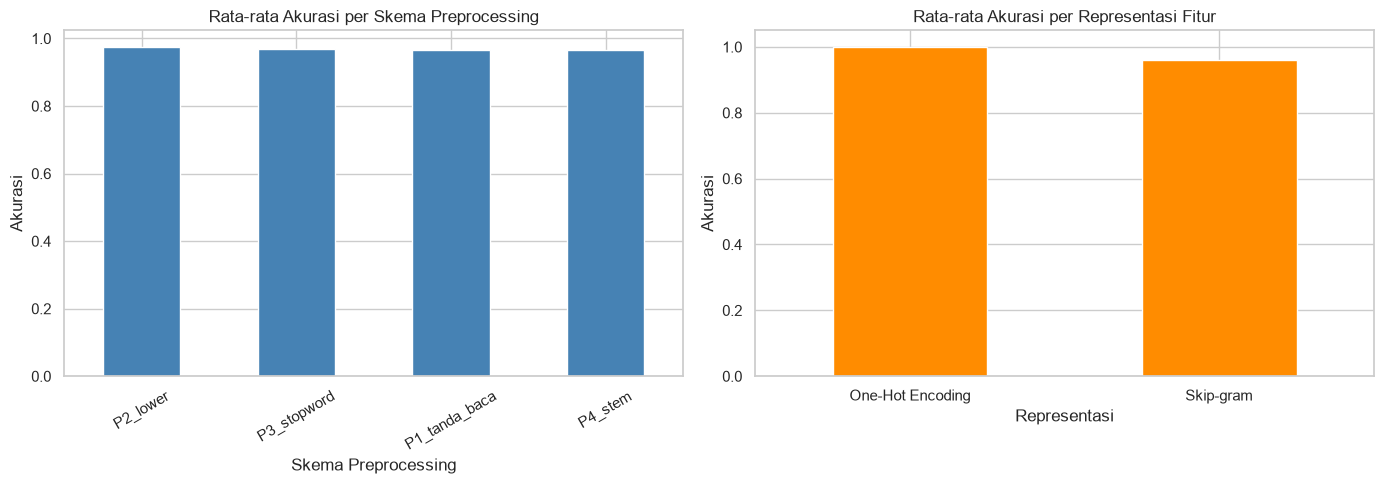

In [18]:
# Visualisasi perbandingan akurasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rata2_per_preprocessing.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Rata-rata Akurasi per Skema Preprocessing")
axes[0].set_ylabel("Akurasi")
axes[0].set_xlabel("Skema Preprocessing")
axes[0].tick_params(axis='x', rotation=30)

rata2_per_representasi.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Rata-rata Akurasi per Representasi Fitur")
axes[1].set_ylabel("Akurasi")
axes[1].set_xlabel("Representasi")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 9. Detail Satu Konfigurasi: Skip-gram + Gaussian Naive Bayes

Tabel rekap hanya menampilkan akurasi. Di sini konfigurasi Skip-gram dengan **akurasi tertinggi** di `df_rekap` (dipilih otomatis) dijalankan lagi lewat fungsi `evaluasi_skipgram` yang sama, untuk melihat *classification report*, *confusion matrix*, dan kata-kata terdekat di ruang embedding. Tidak ada kode pelatihan yang ditulis ulang.

#### Landasan Teori: Gaussian Naive Bayes & Metrik Evaluasi

Naive Bayes memakai **teorema Bayes** dengan asumsi setiap fitur saling bebas jika kelasnya diketahui:

$$P(c \mid \mathbf{x}) = \frac{P(c)\,P(\mathbf{x}\mid c)}{P(\mathbf{x})} \;\propto\; P(c)\prod_{j=1}^{d} P(x_j \mid c)$$

Karena fitur dokumen ($\mathbf{d}_i$) berupa **bilangan real** (bisa negatif), likelihood tiap fitur dimodelkan **Gaussian**:

$$P(x_j \mid c) = \frac{1}{\sqrt{2\pi\sigma_{jc}^{2}}}\exp\!\left(-\frac{\left(x_j - \mu_{jc}\right)^{2}}{2\sigma_{jc}^{2}}\right)$$

Parameter diestimasi dari data latih (*maximum likelihood*):

$$P(c) = \frac{N_c}{N}, \qquad \mu_{jc} = \frac{1}{N_c}\sum_{i:\,y_i=c} x_{ij}, \qquad \sigma_{jc}^{2} = \frac{1}{N_c}\sum_{i:\,y_i=c}\left(x_{ij}-\mu_{jc}\right)^{2}$$

Untuk stabilitas numerik, prediksi dilakukan di ruang log:

$$\hat{c} = \arg\max_{c}\left[\log P(c) + \sum_{j=1}^{d}\log P(x_j \mid c)\right]$$

> Scikit-learn menambahkan konstanta kecil pada varians ($\sigma_{jc}^{2} + \epsilon$, dengan $\epsilon = \text{var\_smoothing} \times \max_j \text{Var}(x_j)$) agar tidak terjadi pembagian dengan nol.

#### Metrik Evaluasi

Dari *confusion matrix* dengan TP, TN, FP, FN (kelas positif = `finance`):

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}, \qquad F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$$

Konfigurasi terbaik : P1_tanda_baca | vector_size=50, window=5
Akurasi Gaussian Naive Bayes : 0.9750
Ukuran kosakata model        : 8665

Classification report:
              precision    recall  f1-score   support

       sport     1.0000    0.9500    0.9744        20
     finance     0.9524    1.0000    0.9756        20

    accuracy                         0.9750        40
   macro avg     0.9762    0.9750    0.9750        40
weighted avg     0.9762    0.9750    0.9750        40



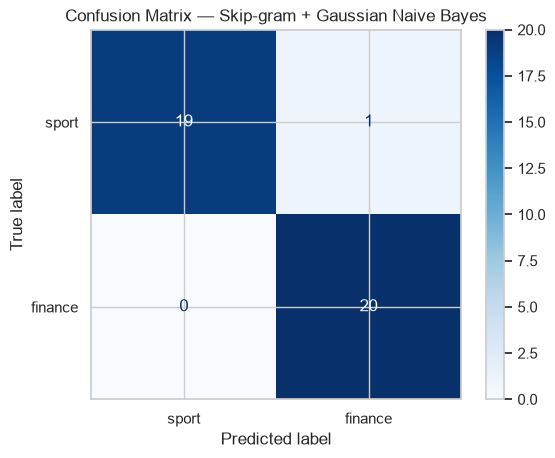


Kata terdekat dengan 'saham':
  lembar          0.7874
  menetapkan      0.7641
  235             0.7628
  pemegang        0.7552
  stagnan         0.7539

Kata terdekat dengan 'gol':
  mencetak        0.8795
  menyamai        0.8366
  penampilan      0.8209
  58              0.7967
  terbanyak       0.7923

Kata terdekat dengan 'rupiah':
  day             0.9179
  puluhan         0.9151
  barrel          0.9103
  Kenaikannya     0.9099
  800             0.9053


In [19]:
# Pilih konfigurasi Skip-gram terbaik dari tabel rekap
best_sg = df_rekap[df_rekap["representasi"] == "Skip-gram"].iloc[0]
BEST_PREP = best_sg["preprocessing"]
BEST_VECTOR_SIZE, BEST_WINDOW = map(int, re.findall(r"\d+", best_sg["parameter"]))
print(f"Konfigurasi terbaik : {BEST_PREP} | vector_size={BEST_VECTOR_SIZE}, window={BEST_WINDOW}")

akurasi, y_pred, model_sg = evaluasi_skipgram(
    prep_results[BEST_PREP], idx_train, idx_test, y_train, y_test,
    vector_size=BEST_VECTOR_SIZE, window=BEST_WINDOW
)
print(f"Akurasi Gaussian Naive Bayes : {akurasi:.4f}")
print("Ukuran kosakata model        :", len(model_sg.wv))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["sport", "finance"], digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["sport", "finance"], cmap="Blues"
)
plt.title("Confusion Matrix — Skip-gram + Gaussian Naive Bayes")
plt.show()

# Kata-kata terdekat (jika ada di kosakata; bila skema memakai stemming, cari bentuk dasarnya)
for kata_uji in ["saham", "gol", "rupiah"]:
    if kata_uji in model_sg.wv:
        print(f"\nKata terdekat dengan '{kata_uji}':")
        for kata, skor in model_sg.wv.most_similar(kata_uji, topn=5):
            print(f"  {kata:15s} {skor:.4f}")

### 10. Kesimpulan

Isi bagian ini berdasarkan tabel `df_rekap` di atas, misalnya:

- Skema preprocessing dengan akurasi rata-rata tertinggi: **(isi otomatis dari hasil run)**
- Representasi fitur terbaik: **One-Hot Encoding** vs **Skip-gram** — bandingkan mana yang lebih stabil/tinggi
- Apakah preprocessing yang lebih "lengkap" (stopword removal + stemming) selalu meningkatkan akurasi, atau justru menurunkannya pada beberapa kombinasi? Jelaskan kemungkinan alasannya (mis. dataset kecil (200 dokumen) membuat Skip-gram kurang optimal karena kosakata training terbatas).
- Rekomendasi kombinasi preprocessing + representasi terbaik untuk kasus ini.


#### Catatan & Interpretasi

- **Skip-gram cocok untuk dataset kecil** seperti 200 artikel ini karena tiap target menghasilkan banyak pasangan latih, sehingga kata jarang tetap mendapat pembaruan vektor.
- **Rata-rata vektor kata** menghilangkan urutan kata dan menyamaratakan bobot semua kata (kata penting dan tidak penting berbobot sama). Alternatifnya adalah rata-rata berbobot TF-IDF.
- **Gaussian Naive Bayes** mengasumsikan tiap dimensi vektor saling bebas dan berdistribusi normal. Asumsi ini tidak sepenuhnya benar untuk *embedding*, sehingga hasilnya bisa lebih rendah dibanding One-Hot + BernoulliNB (bagian 7.1). Bandingkan dan jelaskan alasannya pada bagian Kesimpulan.
- Akurasi dari **satu kali split** pada sekitar 40 dokumen uji bersifat kasar (satu dokumen salah $\approx$ 2,5%). Untuk hasil yang lebih andal gunakan *k-fold cross-validation*.
- Ubah `EPOCHS` dan daftar `VARIASI_SKIPGRAM` untuk melihat pengaruh hiperparameter terhadap akurasi.

#### Kesimpulan

Berdasarkan hasil eksperimen klasifikasi berita menggunakan **Naive Bayes** dengan representasi fitur **One-Hot Encoding** dan **Skip-gram (Word2Vec)**, dapat disimpulkan bahwa hasil akurasi dipengaruhi oleh kombinasi **preprocessing** dan **representasi fitur** yang digunakan.

- Perbedaan preprocessing seperti case folding, stopword removal, dan stemming dapat menghasilkan akurasi yang berbeda pada setiap konfigurasi.
- **One-Hot Encoding** dan **Skip-gram** memiliki karakteristik representasi yang berbeda, sehingga performanya perlu dibandingkan berdasarkan hasil akurasi pada `df_rekap`.
- Preprocessing yang lebih lengkap tidak selalu menghasilkan akurasi yang lebih tinggi. Penghapusan stopword atau stemming dapat menghilangkan informasi tertentu yang masih berguna untuk membedakan kelas berita.
- Pada dataset yang relatif kecil, yaitu **200 dokumen**, Skip-gram dapat memiliki keterbatasan karena jumlah data untuk mempelajari representasi kata masih terbatas.
- Pada Skip-gram, dokumen direpresentasikan menggunakan rata-rata vektor kata. Cara ini tidak mempertahankan urutan kata dan memberikan bobot yang sama pada setiap kata.
- **Gaussian Naive Bayes** memiliki asumsi bahwa setiap dimensi fitur saling bebas dan mengikuti distribusi normal. Asumsi tersebut tidak sepenuhnya sesuai dengan karakteristik embedding, sehingga performanya dapat berbeda dengan One-Hot Encoding + BernoulliNB.
- Evaluasi menggunakan satu kali pembagian data **80% data latih dan 20% data uji** masih memberikan gambaran awal. Untuk evaluasi yang lebih stabil, dapat digunakan *k-fold cross-validation*.

**Kesimpulan akhir:** pemilihan preprocessing dan representasi fitur sebaiknya didasarkan pada hasil eksperimen pada dataset yang digunakan, bukan hanya berdasarkan tingkat kelengkapan preprocessing. Untuk penelitian lanjutan, jumlah dataset dapat diperbesar dan parameter Skip-gram seperti `vector_size`, `window`, dan `epochs` dapat diuji lebih lanjut.